**Name :** Jyoti Vijay Natlekar.       **Roll No** : CS38

**Aim :** To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


**Objectives :**
* Understand SLR
* Load/preprocess dataset
* Perform EDA
* Compute OLS coefficients
* Evaluate with SSE, MSE, R²
* Visualize regression and residual plots









**Software Requirements :**


* Python 3.x
* Jupyter/Colab/VS Code
* Libraries: pandas, numpy, matplotlib, seaborn





**Thoery :**

Linear regression models the relationship between a target continuous variable $y$ and an input feature vector $x$ using a linear equation:

$$
\hat{y} = w_0 + w_1 x_1
$$

In matrix form, including the bias/intercept term $x_0 = 1$:

$$
\hat{y} = Xw
$$

To find the optimal weight vector $\hat{w}$, the **Ordinary Least Squares (OLS)** method minimizes the Sum of Squared Errors (SSE) between actual target values $y$ and predicted values $\hat{y}$:

$$
SSE = \sum_{i=1}^{N}(y_i-\hat{y}_i)^2
= (y-Xw)^T(y-Xw)
$$

Solving for $w$ analytically yields the normal equation:

$$
\hat{w} = (X^T X)^{-1} X^T y
$$

>**Note:** The inverse $(X^T X)^{-1}$ exists only if the matrix $X^T X$ is non-singular (i.e., its determinant is non-zero).

**Algorithm**
1. Import libraries


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2.Load Auto MPG dataset


In [18]:
from google.colab import files
import pandas as pd

# Upload the dataset
uploaded = files.upload()
# Load the dataset
df = pd.read_csv("auto-mpg.csv")
# Display the first 5 rows
print(df.head())

Saving auto-mpg.csv to auto-mpg (2).csv
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


3.Inspect and clean data


In [19]:
# Select only the required columns
df = df[['horsepower', 'mpg']]

# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Remove rows with missing values
df.dropna(inplace=True)

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Display cleaned dataset
print("\nCleaned Dataset:")
print(df.head())

# Display dataset information
print("\nDataset Information:")
print(df.info())

Duplicate rows: 60

Cleaned Dataset:
   horsepower   mpg
0       130.0  18.0
1       165.0  15.0
2       150.0  18.0
3       150.0  16.0
4       140.0  17.0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   horsepower  392 non-null    float64
 1   mpg         392 non-null    float64
dtypes: float64(2)
memory usage: 9.2 KB
None


4. Select horsepower and mpg

In [20]:
# Step 4: Select X and y
X = df['horsepower']
y = df['mpg']

print("X (Horsepower):")
print(X.head())
print("\ny (MPG):")
print(y.head())

X (Horsepower):
0    130.0
1    165.0
2    150.0
3    150.0
4    140.0
Name: horsepower, dtype: float64

y (MPG):
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


5. Plot scatter graph


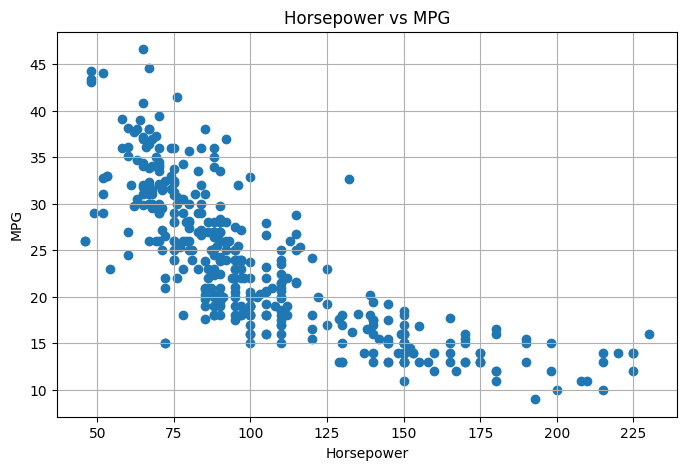

In [21]:
# Step 5: Plot Scatter Graph
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)
plt.show()

6. Add bias term


In [25]:
X_bias = np.column_stack((np.ones(len(X)), X))
print("bias term : ")
print(X_bias[:5])

bias term : 
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


7. Compute correlation


In [26]:
correlation = np.corrcoef(X, y)[0, 1]
print("Correlation Coefficient:", correlation)

Correlation Coefficient: -0.7784267838977756


8. Calculate OLS weights


In [27]:
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
intercept = weights[0]
slope = weights[1]
print("Intercept (β0):", intercept)
print("Slope (β1):", slope)

Intercept (β0): 39.9358610211705
Slope (β1): -0.15784473335365387


9. Predict values


In [28]:
Y_pred = X_bias @ weights
print("First 10 Predicted MPG values:")
print(Y_pred[:10])

First 10 Predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


10. Compute residuals


In [29]:
residuals = y - Y_pred
print("First 10 Residuals:")
print(residuals[:10])

First 10 Residuals:
0   -1.416046
1    1.108520
2    1.740849
3   -0.259151
4   -0.837598
5    6.317396
6    8.789980
7    8.000757
8    9.579204
9    5.054638
Name: mpg, dtype: float64


11. Calculate SSE, MSE, R²


In [30]:
# Sum of Squared Errors
SSE = np.sum(residuals ** 2)

# Mean Squared Error
MSE = SSE / len(y)

# Total Sum of Squares
SST = np.sum((y - np.mean(y)) ** 2)

# R² Score
R2 = 1 - (SSE / SST)

print("Performance Metrics")
print("-------------------")
print("SSE :", SSE)
print("MSE :", MSE)
print("R² Score :", R2)

Performance Metrics
-------------------
SSE : 9385.915871932419
MSE : 23.943662938603108
R² Score : 0.6059482578894348


12. Plot regression and residual graphs


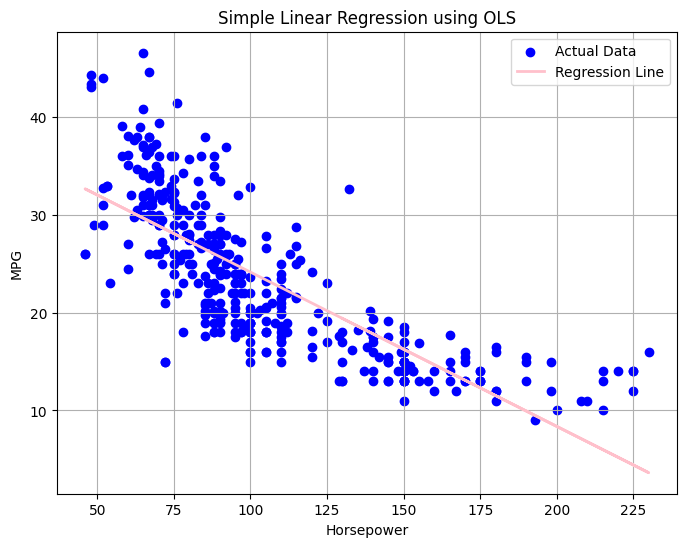

In [32]:
# Step 12A: Plot Regression Line
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='pink', linewidth=2, label='Regression Line')

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression using OLS")
plt.legend()
plt.grid(True)
plt.show()

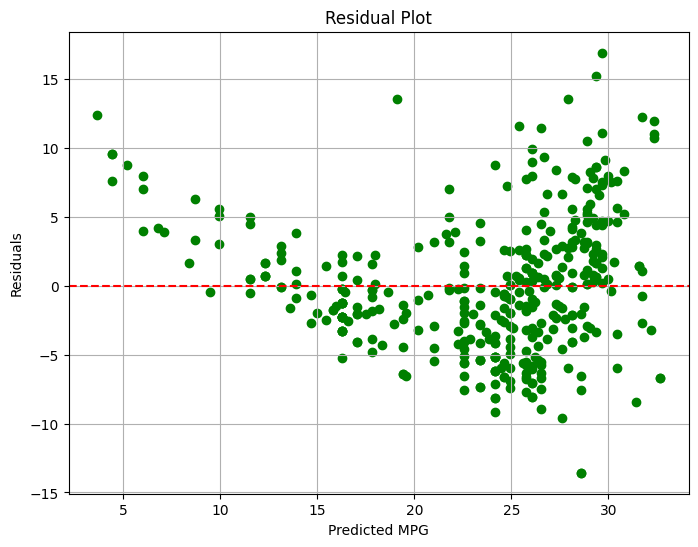

In [33]:
# Step 12B: Plot Residual

plt.figure(figsize=(8,6))
plt.scatter(Y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

13. Interpret results.


In [35]:
print("Interpretation")
print("-----------------------------")

if slope < 0:
    print("• Horsepower and MPG have a negative relationship.")
    print("• As Horsepower increases, MPG decreases.")
else:
    print("• Horsepower and MPG have a positive relationship.")

print(f"• Correlation = {correlation:.4f}")
print(f"• R² Score = {R2:.4f}")

if R2 > 0.8:
    print("• The regression model explains most of the variation in MPG.")
elif R2 > 0.6:
    print("• The regression model provides a reasonably good fit.")
else:
    print("• The regression model has a weak fit.")

Interpretation
-----------------------------
• Horsepower and MPG have a negative relationship.
• As Horsepower increases, MPG decreases.
• Correlation = -0.7784
• R² Score = 0.6059
• The regression model provides a reasonably good fit.
